## Steps

In [3]:
# 1. Data cleaning
# 2. EDA
# 3. Text Preprocessing
# 4. Model building
# 5. Evaluation
# 6. Improvement
# 7. Website
# 8. Deploy

## Importing and Data Load

In [4]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

In [5]:
# Option A: Standard Latin encoding
df = pd.read_csv('spam.csv', encoding='ISO-8859-1')

In [6]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [7]:
df.shape

(5572, 5)

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   v1          5572 non-null   str  
 1   v2          5572 non-null   str  
 2   Unnamed: 2  50 non-null     str  
 3   Unnamed: 3  12 non-null     str  
 4   Unnamed: 4  6 non-null      str  
dtypes: str(5)
memory usage: 217.8 KB


## Data Cleaning

In [9]:
df.isnull().sum()

v1               0
v2               0
Unnamed: 2    5522
Unnamed: 3    5560
Unnamed: 4    5566
dtype: int64

In [10]:
# We will erop last 3 clomuns
df.drop(columns=['Unnamed: 2','Unnamed: 3','Unnamed: 4'],inplace=True)

In [11]:
# Now we will rename our columns
df.rename(columns={
    'v1':'Type',
    'v2':'Text'
},inplace=True)

In [12]:
df.head()

,Type,Text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [13]:
# Now we will encode the value of type
from sklearn.preprocessing import LabelEncoder
encoder= LabelEncoder()

df['Type'] = encoder.fit_transform(df['Type'])

In [14]:
# Looking for missing values
df.isnull().sum().sum()

np.int64(0)

In [15]:
# Looking for dupliate values
df.duplicated().sum()

np.int64(403)

In [16]:
# Removing duplicates
df= df.drop_duplicates(keep='first')

## EDA

In [17]:
df.head()

,Type,Text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [18]:
df['Type'].value_counts()

Type
0    4516
1     653
Name: count, dtype: int64

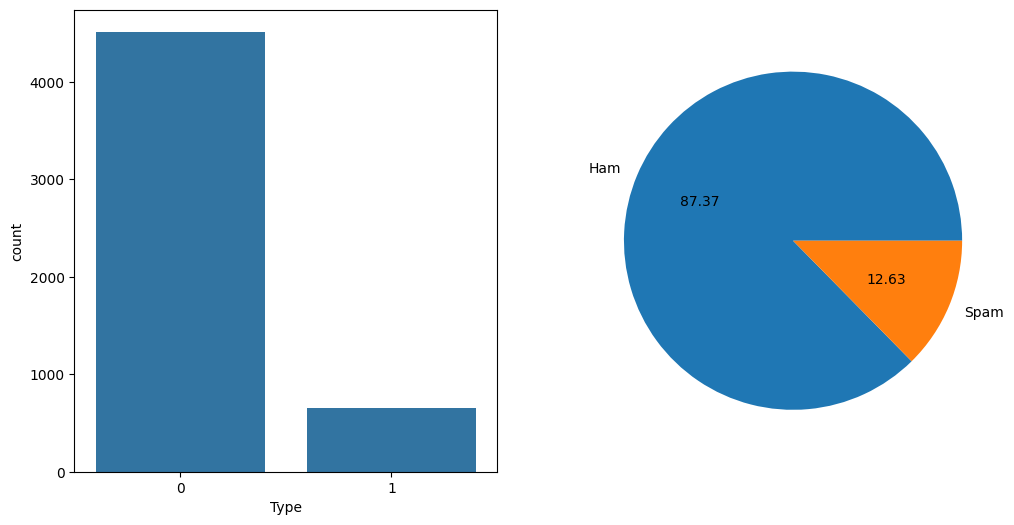

In [19]:
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
sns.countplot(x='Type',data=df)
plt.subplot(1,2,2)
df['Type'].value_counts().plot(kind='pie',autopct='%0.2f',labels=['Ham','Spam'])
plt.show()

#### Seeing this we can say that out data is little imbalenced.....

In [20]:
# Now we have to import a library named nltk to find number of ch,words,sentences in the data
# First of all we have to install this
!pip install nltk

In [21]:
import nltk
nltk.download('punkt') # downloading the package for tokenization
nltk.download('punkt_tab')


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\MSI\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\MSI\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [22]:
df['num_characters'] = df["Text"].apply(len)

In [23]:
# No of words
df['num_words'] = df['Text'].apply(lambda x: len(nltk.word_tokenize(x)))

In [24]:
df['num_sentences']= df['Text'].apply(lambda x: len(nltk.sent_tokenize(x)))

In [25]:
df.head()

,Type,Text,num_characters,num_words,num_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [26]:
df[['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [27]:
# for ham messages
df[df['Type']==0][['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [28]:
# for spam messages
df[df['Type']==1][['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


Text(0.5, 1.0, 'Spam Messages')

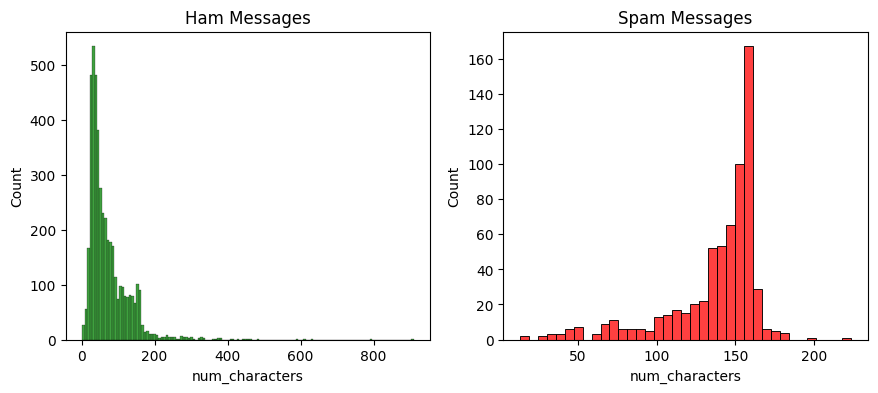

In [29]:
# let's plot the histogram for ham and spam messages
plt.figure(figsize=(16,4))
plt.subplot(1,3,1)
sns.histplot(df[df['Type']==0]['num_characters'],color='green')
plt.title('Ham Messages')
plt.subplot(1,3,2)
sns.histplot(df[df['Type']==1]['num_characters'],color='red')
plt.title('Spam Messages')

Text(0.5, 1.0, 'Spam Messages')

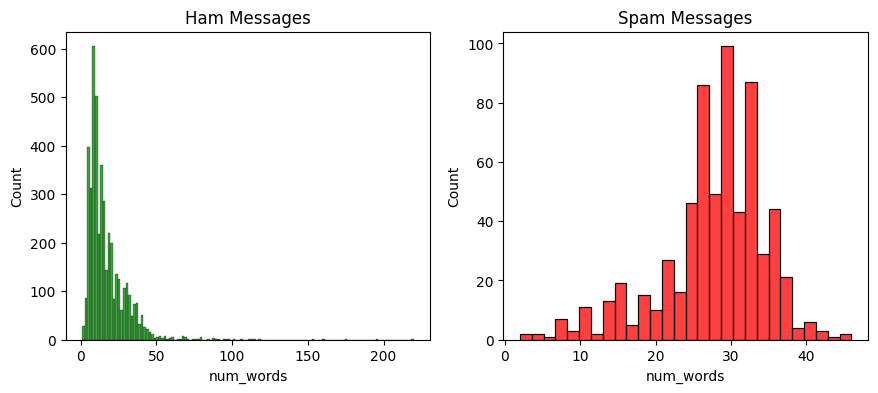

In [30]:
plt.figure(figsize=(16,4))
plt.subplot(1,3,1)
sns.histplot(df[df['Type']==0]['num_words'],color='green')
plt.title('Ham Messages')
plt.subplot(1,3,2)
sns.histplot(df[df['Type']==1]['num_words'],color='red')
plt.title('Spam Messages')

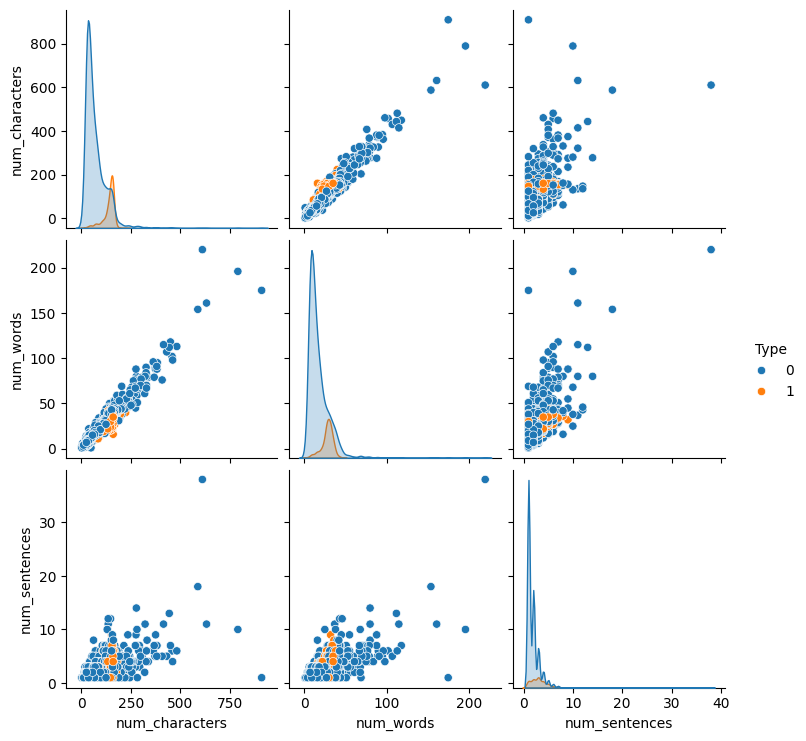

In [31]:
# Let's see the relationship between these features
sns.pairplot(df,hue='Type')

<Axes: >

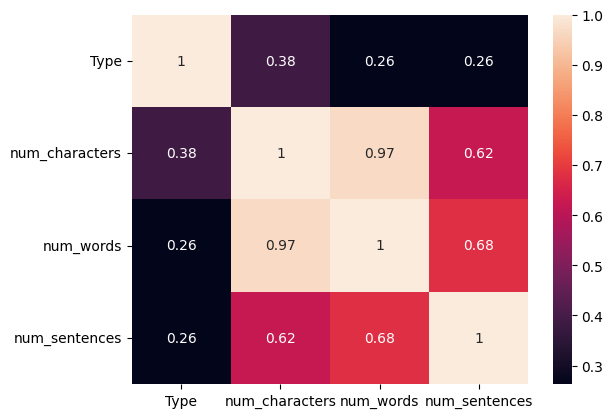

In [32]:
#ignore the text columns and only correlate things like 'num_words', 'num_characters', etc.
sns.heatmap(df.corr(numeric_only=True), annot=True)

## Data/Text preprocessing
#### 1. lowercase
#### 2. Tokenization
#### 3. Removing special character
#### 4. Removing stop words puncution
#### 5. Stemming

In [33]:
# Here we will make a function to do all those thing together
def transform_text(text):
    text = text.lower() # converting the text into lower case
    text = nltk.word_tokenize(text) # tokenization means converting the text into list of words
    y=[]
    for i in text:
        if i.isalnum():
            y.append(i) # removing the special characters

    text = y[:] # copying the list to text
    y.clear() # clearing the list to save memory


    from nltk.corpus import stopwords
    nltk.download('stopwords')
    import string
    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation:
            y.append(i) # removing the stop words and punctuation 
    text = y[:] # copying the list to text
    y.clear() # clearing the list to save memory

    from nltk.stem.porter import PorterStemmer
    ps = PorterStemmer()
    for i in text:
        y.append(ps.stem(i)) # stemming the words

    return "  ".join(y)

In [34]:
df['Transformed_Text'] = df['Text'].apply(transform_text)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\MSI\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\MSI\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\MSI\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\MSI\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\MSI\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\MSI\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_d

In [35]:
df.head()

,Type,Text,num_characters,num_words,num_sentences,Transformed_Text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n grea...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup fina...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [36]:
!pip install wordcloud
from wordcloud import WordCloud

(np.float64(-0.5), np.float64(699.5), np.float64(499.5), np.float64(-0.5))

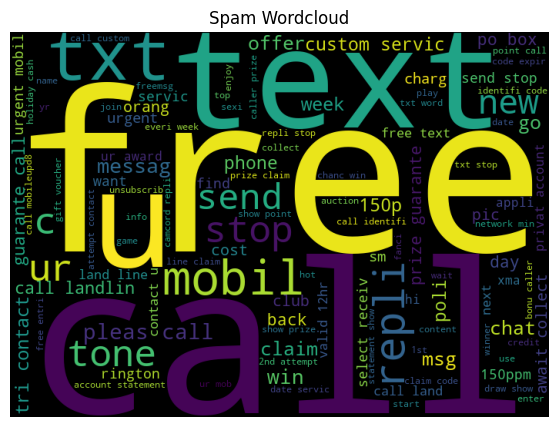

In [37]:
wc = WordCloud(width=700, height=500, min_font_size=10, background_color='black')

wc.generate(df[df['Type']==1]['Transformed_Text'].str.cat(sep=" "))
plt.figure(figsize=(10,5))
plt.imshow(wc)
plt.title("Spam Wordcloud")
plt.axis('off')

(np.float64(-0.5), np.float64(699.5), np.float64(499.5), np.float64(-0.5))

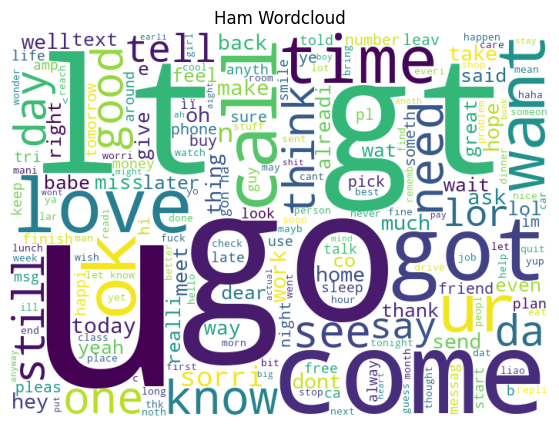

In [38]:
wc = WordCloud(width=700, height=500, min_font_size=10, background_color='white')
wc.generate(df[df['Type']==0]['Transformed_Text'].str.cat(sep=" "))
plt.figure(figsize=(10,5))
plt.imshow(wc)
plt.title("Ham Wordcloud")
plt.axis('off')

In [39]:
# let's top 50 words in ham and spam messages and ham messages
spam_corpus=[]
for message in df[df['Type']==1]['Transformed_Text'].tolist():
    for word in message.split():
        spam_corpus.append(word)

In [40]:
len(spam_corpus)

9939

In [47]:
!pip install collections
from collections import Counter
Counter(spam_corpus).most_common(50)

ERROR: Could not find a version that satisfies the requirement collections (from versions: none)
ERROR: No matching distribution found for collections


[('call', 320),
 ('free', 191),
 ('2', 155),
 ('txt', 141),
 ('text', 122),
 ('u', 119),
 ('ur', 119),
 ('mobil', 114),
 ('stop', 104),
 ('repli', 103),
 ('claim', 98),
 ('4', 97),
 ('prize', 82),
 ('get', 74),
 ('new', 64),
 ('servic', 64),
 ('tone', 63),
 ('send', 60),
 ('urgent', 57),
 ('nokia', 57),
 ('contact', 56),
 ('award', 55),
 ('phone', 52),
 ('cash', 51),
 ('pleas', 51),
 ('week', 49),
 ('win', 48),
 ('c', 45),
 ('collect', 45),
 ('min', 45),
 ('custom', 42),
 ('messag', 42),
 ('guarante', 42),
 ('per', 41),
 ('chat', 38),
 ('tri', 37),
 ('msg', 35),
 ('draw', 35),
 ('number', 35),
 ('cs', 35),
 ('show', 33),
 ('today', 33),
 ('offer', 33),
 ('line', 33),
 ('go', 32),
 ('receiv', 31),
 ('want', 31),
 ('latest', 30),
 ('rington', 30),
 ('landlin', 30)]

In [48]:
ham_corpus=[]
for message in df[df['Type']==0]['Transformed_Text'].tolist():
    for word in message.split():
        ham_corpus.append(word)

## Model Building

In [72]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
cv = CountVectorizer() # bag of words model
tfidf= TfidfVectorizer() # tf-idf model


In [73]:
X= tfidf.fit_transform(df['Transformed_Text']).toarray()
X.shape

(5169, 6708)

In [74]:
y= df['Type'].values

In [75]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
from sklearn.naive_bayes import MultinomialNB, BernoulliNB, GaussianNB
gnb= GaussianNB()
mnb= MultinomialNB()
bnb= BernoulliNB()
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score

In [77]:
# Neive bayes model is usefull in text classification problems
gnb.fit(X_train,y_train)
y_pred1 = gnb.predict(X_test)


print('For GAUSSIAN NAIVE BAYES')
print('-'*60)
print(f'Accuracy score: {accuracy_score(y_test,y_pred1)}')
print(f'Confusion Matrix:\n {confusion_matrix(y_test,y_pred1)}')
print(f'Precision Score:\n {precision_score(y_test,y_pred1)}')

For GAUSSIAN NAIVE BAYES
------------------------------------------------------------
Accuracy score: 0.8636363636363636
Confusion Matrix:
 [[772 117]
 [ 24 121]]
Precision Score:
 0.5084033613445378


In [78]:
mnb.fit(X_train,y_train)
y_pred2 = mnb.predict(X_test)

print('For MULTINOMIAL NAIVE BAYES')
print('-'*60)
print(f'Accuracy score: {accuracy_score(y_test,y_pred2)}')
print(f'Confusion Matrix:\n {confusion_matrix(y_test,y_pred2)}')
print(f'Precision Score:\n {precision_score(y_test,y_pred2)}')

For MULTINOMIAL NAIVE BAYES
------------------------------------------------------------
Accuracy score: 0.9613152804642167
Confusion Matrix:
 [[888   1]
 [ 39 106]]
Precision Score:
 0.9906542056074766


In [79]:
bnb.fit(X_train,y_train)
y_pred3 = bnb.predict(X_test)

print('For BERNOULLI NAIVE BAYES')
print('-'*60)
print(f'Accuracy score: {accuracy_score(y_test,y_pred3)}')
print(f'Confusion Matrix:\n {confusion_matrix(y_test,y_pred3)}')
print(f'Precision Score:\n {precision_score(y_test,y_pred3)}')

For BERNOULLI NAIVE BAYES
------------------------------------------------------------
Accuracy score: 0.9661508704061895
Confusion Matrix:
 [[885   4]
 [ 31 114]]
Precision Score:
 0.9661016949152542


#### Here we will go with (MULTINOMIAL NAIVE BAYES) because it gives most precission

##### Now we will compare our this model to another ml model to compare the result

In [82]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import AdaBoostClassifier
from xgboost import XGBClassifier  
    

In [91]:
svc= SVC(kernel='sigmoid', gamma=1.0)
knn= KNeighborsClassifier(n_neighbors=5)
mnb= MultinomialNB()
dtc= DecisionTreeClassifier(max_depth=5)
lrc= LogisticRegression()
rfc= RandomForestClassifier(n_estimators=100, random_state=42)
gbc= GradientBoostingClassifier(n_estimators=100, random_state=42)
abc= AdaBoostClassifier(n_estimators=100, random_state=42)
xgbc= XGBClassifier(n_estimators=100, random_state=42)

In [92]:
clfs={
    'SVC': svc,
    'KNN': knn,
    'MNB': mnb,
    'DTC': dtc,
    'LRC': lrc,
    'RFC': rfc,
    'GBC': gbc,
    'ABC': abc,
    'XGBC': xgbc
}

In [93]:
def train_classifier(clf, X_train, y_train, X_test, y_test):
    clf.fit(X_train, y_train) # training the model
    y_pred = clf.predict(X_test) # predicting the test set results
    accuracy = accuracy_score(y_test, y_pred) # calculating the accuracy score
    precision = precision_score(y_test, y_pred) # calculating the precision score
    return accuracy, precision

In [94]:
train_classifier(svc, X_train, y_train, X_test, y_test)

(0.971953578336557, 0.9393939393939394)

In [ ]:
accuracy_score= []
precision_score= []

for name,clf in clfs.items():
    current_accuracy,current_precision = train_classifier(clf, X_train,y_train,X_test,y_test)

    print("For ",name)
    print(f"Accuracy: {current_accuracy}")
    print(f"Precision: {current_precision}")

    accuracy_score.append(current_accuracy)
    precision_score.append(current_precision)
